In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from python_utils.visualization_utils import create_summary_table, plot_snr_performance

In [2]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# 10 by 5 Mixing with Correlated Sources

In [3]:
df_predictiveBSS = pd.read_pickle(r"../Results/predictive_bss_correlated_nnantisparse_10by5_results.pkl")
df_predictiveBSS.tail()

,Model,seed,rho,SINR,SNR,SNRinp,execution_time
1645,PredictiveDecorrBSS,2901,0.5,22.965622,"[[21.781779713954347, 22.13768166230999, 23.18...",30,7.717772
1646,CorInfoMaxBSS,2901,0.5,25.146147,"[[24.27330107148361, 25.009196113179733, 25.09...",30,7.350170
1647,ICA_InfoMax,2901,0.5,8.054829,"[[15.696041723578826, 6.391136170697945, 6.306...",30,6.145842
1648,LDMIBSS,2901,0.5,33.316204,"[[32.36586295993943, 32.65149323428593, 33.738...",30,13.032412
1649,NSMBSS,2901,0.5,5.632686,"[[3.435741596175739, 7.553780376115309, 8.7083...",30,14.310047


In [4]:
df_upem = pd.read_pickle(r"../Results/upem_correlated_nnantisparse_10by5_results.pkl")
k = len(df_predictiveBSS["Model"].unique())
def interleave(A, B,k):
    nA, nB = len(A), len(B)

    # Group index for A (every k rows = one group)
    groups_A = np.arange(nA) // k

    # Position within each group (A rows come first)
    pos_A = np.arange(nA) % k

    # Build DataFrame with ordering keys
    A_ = A.copy()
    A_['_grp'] = groups_A
    A_['_pos'] = pos_A
    A_['_src'] = 0  # A comes before B within group

    # For B: one row per group
    B_ = B.iloc[:groups_A.max() + 1].copy()
    B_['_grp'] = np.arange(len(B_))
    B_['_pos'] = k   # comes after the 5 A rows
    B_['_src'] = 1

    # Combine and sort once
    out = pd.concat([A_, B_], ignore_index=True)
    out = out.sort_values(['_grp', '_pos', '_src'])

    return out.drop(columns=['_grp', '_pos', '_src']).reset_index(drop=True)
df_combined = interleave(df_predictiveBSS, df_upem,k)

In [5]:
summary_df = create_summary_table(df_combined)
summary_df

,,,SINR (dB),mSNR (dB),Time (s)
Model,rho,SNRinp,,,
CorInfoMaxBSS,0.0,30,25.79 ± 0.42,26.15 ± 0.39,8.92 ± 0.20
ICA_InfoMax,0.0,30,25.31 ± 0.63,26.05 ± 0.51,7.73 ± 0.14
LDMIBSS,0.0,30,28.89 ± 0.86,30.05 ± 0.59,15.70 ± 1.12
NSMBSS,0.0,30,29.51 ± 0.70,30.09 ± 0.60,16.70 ± 0.34
PredictiveDecorrBSS,0.0,30,26.15 ± 0.50,26.50 ± 0.35,9.03 ± 1.26
...,...,...,...,...,...
ICA_InfoMax,0.5,30,7.86 ± 0.15,10.14 ± 0.08,6.28 ± 0.07
LDMIBSS,0.5,30,29.97 ± 0.95,31.26 ± 0.61,13.23 ± 0.24
NSMBSS,0.5,30,7.26 ± 0.32,7.57 ± 0.28,15.44 ± 0.81


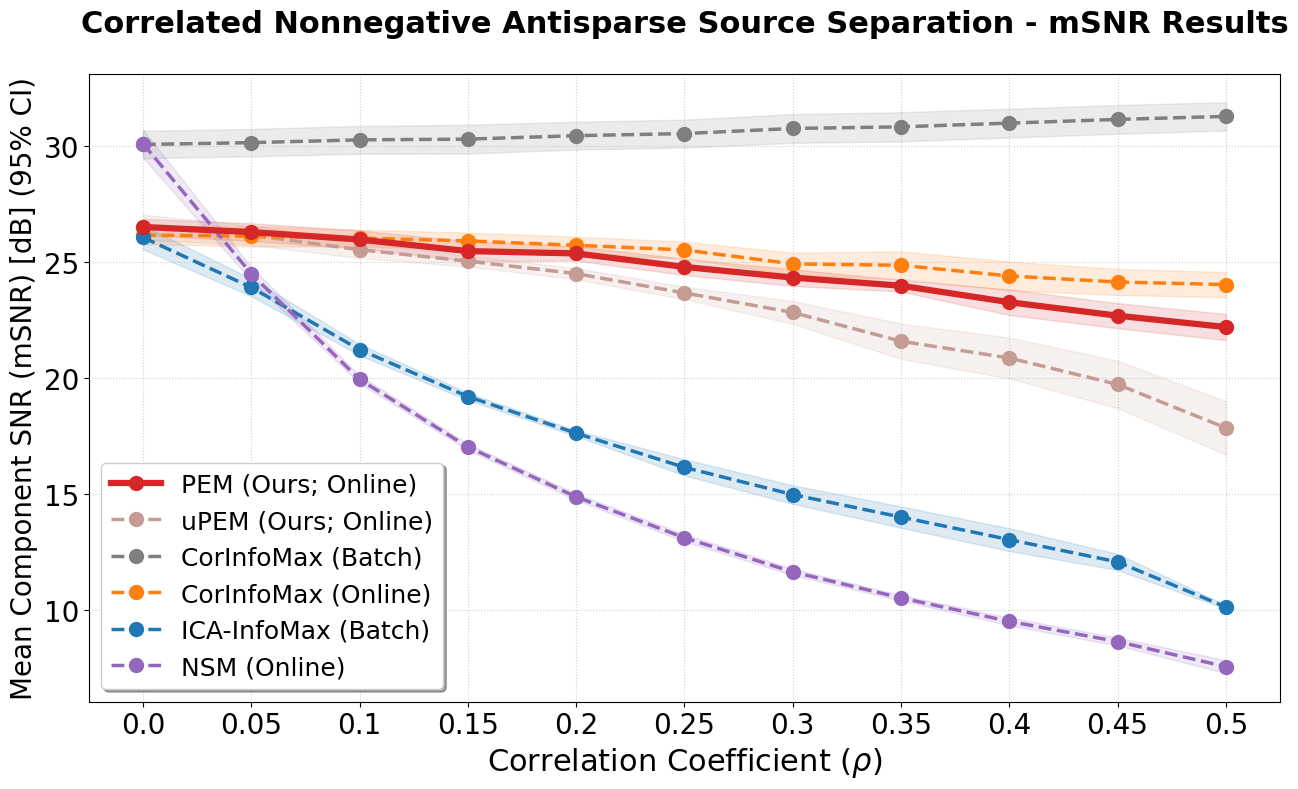

In [6]:
plot_title = "Correlated Nonnegative Antisparse Source Separation - mSNR Results"
bss_plot = plot_snr_performance(summary_df, title = plot_title)
# plt.savefig('Figures/NNAntisparse_Correlated_Comparison.pdf', format='pdf', bbox_inches = 'tight')
bss_plot.show()